# Stage 1 Preprocessing — Raw Data to Analysis-Ready Matrices

Converts raw MGX/MBX/HTX omics data into the standardized, network-ready matrices
GLASSO consumes. See the next cell for the preprocessing stages in order.

**RUN**

Headlessly via `01_run_pipeline.py` (executes cells 1-11; cell 12, network
visualization, needs a graphml GLASSO has not produced yet at this point, so
it is excluded and reattached unexecuted), or interactively top to bottom.

## Step 1 (Universal) — Cross-Layer Subject Intersection and Shared Constants

The cross-layer subject intersection is computed **first**, before any layer-specific
processing, so that prevalence filtering, transformation and differential testing all
operate on the same participant set that the network is ultimately built on. This is the
order described in Methodology Step 1; the earlier implementation deferred the
intersection to the end, which meant MGX selected features using 130 participants and MBX
using 106, including participants absent from the final 90-participant network.

`PREVALENCE_THRESHOLD` is defined here once and imported by all three layer cells, so the
filter can be re-tuned in a single place.

In [2]:
# ── Universal Step 1: cross-layer subject intersection + shared constants ─────
import pandas as pd
import numpy as np

META_PATH = "Data/hmp2_metadata_2018-08-20.csv"
MGX_PATH  = "Data/Unprocessed_Other/mgx_species_abundances_raw.tsv"
MBX_PATH  = "Data/Unprocessed_Other/mbx_metabolomics_raw.tsv"
RNA_PATH  = "Data/Unprocessed_Other/rna_transcriptomics_raw.tsv"

# Shared across all three layer cells. Changing it here changes every layer.
PREVALENCE_THRESHOLD = 0.10   # 10%: MaAsLin2 default (Mallick et al. 2021)
NODE_BUDGET          = 25
GROUP_MAP            = {"CD": "IBD", "UC": "IBD", "nonIBD": "nonIBD"}

LOCATION_PRIORITY = [
    "Rectum", "Ileum", "Sigmoid Colon", "Transverse colon",
    "Descending (left-sided) colon", "Ascending (right-sided) colon",
    "Cecum", "Terminal ileum", "Non-inflamed",
]

meta = pd.read_csv(META_PATH, low_memory=False)

# --- participants with usable MGX samples -----------------------------------
mgx_cols = pd.read_csv(MGX_PATH, sep="\t", index_col=0, nrows=0).columns
eid_map = (
    meta[["External ID", "Participant ID"]]
    .assign(eid_clean=lambda df: df["External ID"].str.replace(
        r"_P_profile$|_profile$|_P$", "", regex=True))
    .drop_duplicates("eid_clean").set_index("eid_clean")["Participant ID"]
)
mgx_clean = pd.Index(mgx_cols).str.replace(r"_P_profile$|_profile$|_P$", "", regex=True)
mgx_participants = set(eid_map.reindex(mgx_clean).dropna())

# --- participants with usable MBX samples -----------------------------------
mbx_cols = pd.read_csv(MBX_PATH, sep="\t", index_col=0, nrows=0).columns
eid_plain = meta.drop_duplicates("External ID").set_index("External ID")["Participant ID"]
mbx_participants = set(eid_plain.reindex(pd.Index(mbx_cols)).dropna())

# --- participants with a usable baseline HTX biopsy -------------------------
rna_cols = pd.read_csv(RNA_PATH, sep="\t", index_col=0, nrows=0).columns
htx_meta = meta[(meta["data_type"] == "host_transcriptomics")
                & (meta["IntervalName"] == "Screening Colonoscopy")]
htx_participants = set(htx_meta.loc[htx_meta["External ID"].isin(rna_cols), "Participant ID"])

CROSS_LAYER_PARTICIPANTS = sorted(mgx_participants & mbx_participants & htx_participants)
print(f"MGX participants : {len(mgx_participants)}")
print(f"MBX participants : {len(mbx_participants)}")
print(f"HTX participants : {len(htx_participants)}")
print(f"Cross-layer intersection (used for ALL downstream steps): {len(CROSS_LAYER_PARTICIPANTS)}")

pd.Series(CROSS_LAYER_PARTICIPANTS, name="Participant ID").to_csv(
    "Data/cross_layer_participants.csv", index=False)

_diag = meta.drop_duplicates("Participant ID").set_index("Participant ID")["diagnosis"]
print("\nDiagnosis breakdown of the intersection:")
print(_diag.reindex(CROSS_LAYER_PARTICIPANTS).map(GROUP_MAP).value_counts().to_string())


MGX participants : 130
MBX participants : 106
HTX participants : 90
Cross-layer intersection (used for ALL downstream steps): 90

Diagnosis breakdown of the intersection:
diagnosis
IBD       68
nonIBD    22


## Multi-Layer Data Preprocessing

Preprocessing is organised into two stages: layer-specific normalisation pipelines, then universal cross-layer steps. The three layers are measured on different scales and with different technologies. Layer-specific transformations map each to approximately Gaussian continuous values; cross-layer z-score standardisation then ensures all features have mean 0 and variance 1 before concatenation into the joint input matrix for GLASSO. Diagnosis is coded as a binary IBD (CD and UC pooled) vs. nonIBD grouping throughout, reflecting the small overall sample size (n=90).

**Layer-specific pipelines (run first, in order HTX → MGX → MBX):**
- HTX: DESeq2 (size factor normalisation → empirical Bayes dispersion estimation → Wald DE testing → VST). Baseline sample selected before modelling. DE genes selected as HTX nodes.
- MGX: Centred log-ratio (CLR) transformation. Zeros replaced with half the minimum non-zero value across the dataset (pseudocount). Per-subject median computed after CLR. Differentially abundant species (Mann-Whitney U, Benjamini-Hochberg FDR) selected as MGX nodes, targeting 20–30 species.
- MBX: Log2 transformation. Zeros imputed as half the minimum detected value per metabolite. Per-subject median computed after log2. Differentially abundant metabolites (Mann-Whitney U, Benjamini-Hochberg FDR) selected as MBX nodes, targeting 20–30 metabolites.

**Universal cross-layer steps (run after layer-specific pipelines):**
1. Subject intersection — retain only subjects present in all three layers.
2. Z-score standardisation — each feature standardised column-wise to mean 0, variance 1 across matched subjects. This makes partial correlations directly comparable across layers in GLASSO and gives the regularisation parameter λ a consistent interpretation for within-layer and cross-layer edges.
3. Output — standardised matrices saved to GLASSO/data/ for network inference.

## MGX Layer — Centred Log-Ratio (CLR) Pipeline

Metagenomics relative abundances are compositional data (values sum to 1 per sample), which induces spurious negative correlations in Gaussian graphical models. The centred log-ratio (CLR) transformation resolves this by mapping abundances to unconstrained real-valued space. Zeros are replaced with a pseudocount equal to half the minimum non-zero value observed across the dataset before log transformation. Per-subject median CLR is computed across all available timepoints (after transformation, as CLR is nonlinear). Differentially abundant species between IBD (CD and UC pooled) and nonIBD are selected as MGX network nodes (Mann-Whitney U test, Benjamini-Hochberg FDR correction, targeting 20–30 species).

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests

MGX_PATH  = "Data/Unprocessed_Other/mgx_species_abundances_raw.tsv"
META_PATH = "Data/hmp2_metadata_2018-08-20.csv"
# PREVALENCE_THRESHOLD, NODE_BUDGET and CROSS_LAYER_PARTICIPANTS come from the
# Universal Step 1 cell above; not redefined here so there is one source of truth.
_KEEP = set(pd.read_csv("Data/cross_layer_participants.csv")["Participant ID"])
PADJ_STRICT  = 0.05   # reported for context only, not used to gate selection
PADJ_RELAXED = 0.20   # reported for context only, not used to gate selection

# ── 1. Load ────────────────────────────────────────────────────────────────────
mgx_raw = pd.read_csv(MGX_PATH, sep="\t", index_col=0)
print(f"Raw shape (features × samples): {mgx_raw.shape}")

# ── 2. Filter to species-level rows (contain '|s__') ──────────────────────────
species_mask = mgx_raw.index.str.contains(r"\|s__", regex=True)
mgx_species = mgx_raw.loc[species_mask].copy()
mgx_species.index = mgx_species.index.str.extract(r"\|s__(.+)$")[0]
print(f"After species filter: {mgx_species.shape[0]} species × {mgx_species.shape[1]} samples")

# ── 3. Transpose → samples × species; strip _P_profile/_profile/_P suffixes ───
mgx = mgx_species.T.astype(float)
mgx.index = mgx.index.str.replace(r"_P_profile$|_profile$|_P$", "", regex=True)

# ── 3b. Restrict to the cross-layer intersection BEFORE filtering/testing ─────
# Universal Step 1: every downstream step uses the same participant set the
# network is built on. Samples from participants outside the intersection are
# dropped here rather than at the end of the pipeline.
_pid_of_sample = (
    pd.read_csv(META_PATH, usecols=["External ID", "Participant ID"])
    .assign(c=lambda d: d["External ID"].str.replace(r"_P_profile$|_profile$|_P$", "", regex=True))
    .drop_duplicates("c").set_index("c")["Participant ID"]
)
mgx = mgx.loc[[s for s in mgx.index if _pid_of_sample.get(s) in _KEEP]]
print(f"After cross-layer intersection: {mgx.shape[0]} samples from {len(_KEEP)} participants")

# ── 4. Prevalence filter (≥ threshold of samples with relative abundance > 0) ──
prevalence = (mgx > 0).mean(axis=0)
mgx = mgx.loc[:, prevalence >= PREVALENCE_THRESHOLD]
print(f"After prevalence filter (≥{PREVALENCE_THRESHOLD*100:.0f}%): {mgx.shape[1]} species retained")

# ── 5. Pseudocount: replace zeros with half the minimum non-zero value ─────────
# Applied dataset-wide before log so all entries are strictly positive.
min_nonzero = mgx.values[mgx.values > 0].min()
pseudocount = min_nonzero / 2
mgx_pseudo = mgx.where(mgx > 0, pseudocount)
print(f"Pseudocount applied: {pseudocount:.2e}")

# ── 6. CLR transform: log(x) − geometric mean per sample ──────────────────────
log_mgx = np.log(mgx_pseudo)
mgx_clr = log_mgx.subtract(log_mgx.mean(axis=1), axis=0)

# ── 7. Map External IDs → Participant IDs; per-participant median ──────────────
meta = pd.read_csv(META_PATH, usecols=["External ID", "Participant ID", "diagnosis"])
# Strip _P / _P_profile / _profile from metadata External IDs to match the
# stripped MGX sample IDs. The raw MGX file mixes two suffix conventions
# (_P_profile for 300 samples, bare _profile for 1,338 samples); missing the
# bare _profile case left 1,338/1,638 samples unmapped and silently dropped.
eid_meta = (
    meta[["External ID", "Participant ID"]]
    .assign(eid_clean=lambda df: df["External ID"].str.replace(r"_P_profile$|_profile$|_P$", "", regex=True))
    .drop_duplicates("eid_clean")
    .set_index("eid_clean")
)
mgx_clr.index = mgx_clr.index.map(eid_meta["Participant ID"])
mgx_clr = mgx_clr[mgx_clr.index.notna()]
mgx_clr_p = mgx_clr.groupby(mgx_clr.index).median()
print(f"After participant aggregation (median CLR): {mgx_clr_p.shape[0]} participants")

# ── 7b. Save the full prevalence-filtered candidate pool (pre-selection) ──────
# For EDA's selection-bias check: are DA-selected species more extreme than a
# typical candidate feature? Not used by any downstream network-inference step.
mgx_clr_p.to_csv("Data/mgx_species_clr_full_pool.csv")
print(f"Saved full candidate pool ({mgx_clr_p.shape[0]} x {mgx_clr_p.shape[1]}) to Data/mgx_species_clr_full_pool.csv")

# ── 8. Diagnosis labels per participant (binary: CD and UC pooled into IBD) ───
pid_diag = meta.drop_duplicates("Participant ID").set_index("Participant ID")["diagnosis"]
diagnosis = pid_diag.reindex(mgx_clr_p.index)
GROUP_MAP = {"CD": "IBD", "UC": "IBD", "nonIBD": "nonIBD"}
ibd_group = diagnosis.map(GROUP_MAP)

# ── 9. Differential abundance: Mann-Whitney U, IBD vs nonIBD ───────────────────
mwu_pvals, effect_sizes = [], []
_ibd_idx = ibd_group[ibd_group == "IBD"].index
_non_idx = ibd_group[ibd_group == "nonIBD"].index
_n1, _n2 = len(_ibd_idx), len(_non_idx)
for species in mgx_clr_p.columns:
    ibd_vals = mgx_clr_p.loc[_ibd_idx, species].values
    non_vals = mgx_clr_p.loc[_non_idx, species].values
    u, p = stats.mannwhitneyu(ibd_vals, non_vals, alternative="two-sided")
    mwu_pvals.append(p)
    effect_sizes.append(2.0 * u / (_n1 * _n2) - 1.0)   # rank-biserial correlation

_, padj, _, _ = multipletests(mwu_pvals, method="fdr_bh")
da_results = pd.Series(padj, index=mgx_clr_p.columns).sort_values()
effect = pd.Series(effect_sizes, index=mgx_clr_p.columns).abs()
n_strict = (da_results < PADJ_STRICT).sum()
print(f"Differentially abundant species: {n_strict} at padj < {PADJ_STRICT}")

# ── 10. Two-stage rank and cap: significance gate, then effect-size ranking ──
# Same rule as MBX, so both Mann-Whitney layers select identically.
_sig = da_results[da_results < PADJ_STRICT].index
print(f"Stage 1 (padj<{PADJ_STRICT}): {len(_sig)} species eligible")
if len(_sig) < NODE_BUDGET:
    print(f"  fewer than {NODE_BUDGET} significant; falling back to adjusted p-value ranking")
    selected = da_results.iloc[:NODE_BUDGET]
else:
    _ranked = effect.loc[_sig].sort_values(ascending=False)
    selected = da_results.loc[_ranked.index[:NODE_BUDGET]]
n_strict_sel = (selected < PADJ_STRICT).sum()
print(f"Stage 2 (top {NODE_BUDGET} of those by |rank-biserial effect size|) selected as MGX network nodes")
print(f"  Of these, {n_strict_sel} pass padj<{PADJ_STRICT}; effect size range "
      f"{effect.loc[selected.index].min():.3f}-{effect.loc[selected.index].max():.3f}")

mgx_final = mgx_clr_p[selected.index]
print(f"\nFinal MGX matrix (participants × species, CLR): {mgx_final.shape}")
print(mgx_final.describe().round(3))

# ── 11. Save (participant-level, CLR-transformed, DA-selected species) ─────────
OUT_PATH = "Data/mgx_species_clr_processed.csv"
mgx_final.to_csv(OUT_PATH)
print(f"\nSaved to {OUT_PATH}")

Raw shape (features × samples): (932, 1638)
After species filter: 578 species × 1638 samples
After cross-layer intersection: 1441 samples from 90 participants
After prevalence filter (≥10%): 124 species retained
Pseudocount applied: 7.50e-05
After participant aggregation (median CLR): 90 participants
Saved full candidate pool (90 x 124) to Data/mgx_species_clr_full_pool.csv
Differentially abundant species: 26 at padj < 0.05
Stage 1 (padj<0.05): 26 species eligible
Stage 2 (top 25 of those by |rank-biserial effect size|) selected as MGX network nodes
  Of these, 25 pass padj<0.05; effect size range 0.378-0.591

Final MGX matrix (participants × species, CLR): (90, 25)


0      Dielma_fastidiosa  Erysipelatoclostridium_ramosum   
count             90.000                          90.000  \
mean              -2.004                          -2.162   
std                1.690                           1.986   
min               -4.059                          -4.255   
25%               -3.020                          -3.133   
50%               -2.569                          -2.737   
75%               -1.579                          -2.138   
max                3.817                           7.117   

0      Clostridium_lavalense  Veillonella_atypica  Clostridium_sp_CAG_242   
count                 90.000               90.000                  90.000  \
mean                  -1.770               -1.796                  -2.103   
std                    1.955                2.248                   1.880   
min                   -4.257               -4.080                  -4.257   
25%                   -2.937               -3.100                  -3.165 

## HTX Layer — DESeq2 Pipeline

Following baseline sample selection (Universal Step 2) and prevalence filtering (Universal Step 3), the HTX count matrix is processed through DESeq2 to produce variance-stabilised expression values for Graphical LASSO input. Differentially expressed genes between IBD (CD and UC pooled) and nonIBD are selected as HTX network nodes.

In [4]:
import pandas as pd
import numpy as np
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

RNA_PATH     = "Data/Unprocessed_Other/rna_transcriptomics_raw.tsv"
META_PATH    = "Data/hmp2_metadata_2018-08-20.csv"
# PREV_THRESH mirrors PREVALENCE_THRESHOLD from Universal Step 1 (one source of truth).
PREV_THRESH  = PREVALENCE_THRESHOLD   # ≥ threshold of subjects with ≥ MIN_READS raw counts
MIN_READS    = 10
PADJ_STRICT  = 0.05   # reported for context only, not used to gate selection
LFC_STRICT   = 1.0   # reported for context only, not used to gate selection
NODE_BUDGET  = 25   # rank-and-cap: top N genes by adjusted p-value

GROUP_MAP = {"CD": "IBD", "UC": "IBD", "nonIBD": "nonIBD"}

# ── TEST MODE ──────────────────────────────────────────────────────────────────
# Set TEST_MODE = True to cap genes before DESeq2 (fast sanity check, ~2 min).
# Set TEST_MODE = False for the real run.
TEST_MODE       = False
TEST_N_GENES    = 500   # top genes by mean count kept for DESeq2

# ── 1. Load raw counts ────────────────────────────────────────────────────────
rna_raw = pd.read_csv(RNA_PATH, sep="\t", index_col=0)
print(f"Raw: {rna_raw.shape[0]:,} transcripts × {rna_raw.shape[1]} samples")

# ── 2. Select one baseline sample per participant ──────────────────────────────
# HTX samples are intestinal biopsies from the Screening Colonoscopy visit.
# 89/90 participants have multiple biopsy locations sampled at that same visit.
# Location is chosen by a fixed priority order (most prevalent location in the
# cohort first), not by alphabetical sort on External ID: alphabetical sorting
# was found to systematically over-select Ileum over the more common Rectum
# (since "Ileum" < "Rectum" alphabetically), which introduces uncontrolled,
# location-driven expression variance unrelated to diagnosis (ileal and rectal
# tissue have genuinely different baseline transcriptional profiles). Rectum is
# both the most-sampled location overall and its diagnosis breakdown (69 IBD:
# 44 CD + 25 UC / 22 nonIBD) closely matches the full 90-participant cohort
# breakdown (68 IBD / 22 nonIBD), making it a defensible default rather than an
# arbitrary choice.
LOCATION_PRIORITY = [
    "Rectum", "Ileum", "Sigmoid Colon", "Transverse colon",
    "Descending (left-sided) colon", "Ascending (right-sided) colon",
    "Cecum", "Terminal ileum", "Non-inflamed",
]
meta = pd.read_csv(META_PATH, usecols=["External ID", "Participant ID", "data_type", "IntervalName", "diagnosis", "biopsy_location"])
htx_meta = (
    meta[(meta["data_type"] == "host_transcriptomics") & (meta["IntervalName"] == "Screening Colonoscopy")]
    .drop_duplicates("External ID")
    .reset_index(drop=True)
)
# Filter to samples actually present in the raw counts file BEFORE selecting a
# representative per participant --- doing this check afterward (as the
# original alphabetical version did) can pick an unavailable sample and drop
# a participant entirely even when they have another valid, sequenced sample
# at a different location (found for participant H4039: its alphabetically/
# priority-first sample, a Rectum biopsy, is missing from the raw counts file,
# even though that participant also has valid Ileum and Ascending colon
# samples that were being discarded unnecessarily).
htx_meta = htx_meta[htx_meta["External ID"].isin(rna_raw.columns)]
# Universal Step 1: restrict to the cross-layer intersection before filtering/testing.
# (HTX already resolves to ~90 participants, so this is usually a no-op, but it makes
# the same rule explicit in all three layers rather than implicit in one.)
_KEEP = set(pd.read_csv("Data/cross_layer_participants.csv")["Participant ID"])
htx_meta = htx_meta[htx_meta["Participant ID"].isin(_KEEP)]
htx_meta["location_rank"] = htx_meta["biopsy_location"].apply(
    lambda loc: LOCATION_PRIORITY.index(loc) if loc in LOCATION_PRIORITY else len(LOCATION_PRIORITY)
)
per_participant = (
    htx_meta.sort_values(["Participant ID", "location_rank", "External ID"])
    .groupby("Participant ID", sort=True)
    .first()   # highest-priority available biopsy location per participant; alphabetical External ID only breaks ties within the same location
    .reset_index()
)
print(f"Baseline samples selected (one per participant): {len(per_participant)}")

# ── 3. Build count matrix (samples × genes) ───────────────────────────────────
counts = rna_raw[per_participant["External ID"].values].T.astype(int)
counts.index = per_participant["Participant ID"].values
sample_meta = pd.DataFrame(
    {"diagnosis": per_participant["diagnosis"].values},
    index=per_participant["Participant ID"].values,
)
# Binary grouping: CD and UC pooled into a single IBD level, nonIBD as reference.
sample_meta["ibdgroup"] = sample_meta["diagnosis"].map(GROUP_MAP)

# ── 4. Prevalence filter: ≥20% of subjects with ≥ MIN_READS raw counts ────────
prevalence = (counts >= MIN_READS).mean(axis=0)
counts = counts.loc[:, prevalence >= PREV_THRESH]
print(f"After prevalence filter ({PREV_THRESH*100:.0f}%, ≥{MIN_READS} reads): {counts.shape[1]} genes")

# ── 4b. TEST MODE: cap to top N genes by mean count ───────────────────────────
if TEST_MODE:
    mean_counts = counts.mean(axis=0).sort_values(ascending=False)
    counts = counts[mean_counts.iloc[:TEST_N_GENES].index]
    print(f"TEST MODE: capped to top {TEST_N_GENES} genes by mean count")

# ── 5. Build DESeqDataSet ──────────────────────────────────────────────────────
dds = DeseqDataSet(
    counts=counts,
    metadata=sample_meta,
    design_factors="ibdgroup",
    ref_level=["ibdgroup", "nonIBD"],
    quiet=True,
)
print(f"DESeqDataSet: {dds.n_obs} subjects × {dds.n_vars} genes")

# ── 6. Size factor estimation + dispersion estimation (full DESeq2 pipeline) ──
print("Running DESeq2 (median-of-ratios normalisation + empirical Bayes dispersion)...")
dds.deseq2()

# ── 7. Variance-stabilising transformation (blind=False: use design dispersions)
print("Applying VST (use_design=True)...")
dds.vst(use_design=True)
vst_matrix = pd.DataFrame(
    dds.layers["vst_counts"],
    index=dds.obs_names,
    columns=dds.var_names,
)

# ── 7b. Save the full prevalence-filtered candidate pool (pre-selection) ──────
# For EDA's selection-bias check: are DE-selected genes more extreme than a
# typical candidate gene? Not used by any downstream network-inference step.
vst_matrix.to_csv("Data/rna_transcriptomics_vst_full_pool.csv")
print(f"Saved full candidate pool ({vst_matrix.shape[0]} x {vst_matrix.shape[1]}) to Data/rna_transcriptomics_vst_full_pool.csv")

# ── 8. Wald DE test: IBD vs nonIBD ────────────────────────────────────────────
stat_res = DeseqStats(dds, contrast=["ibdgroup", "IBD", "nonIBD"], alpha=PADJ_STRICT, quiet=True)
stat_res.run_wald_test()
stat_res.summary()
# apeGLM shrinkage of the log2 fold changes (Zhu et al. 2019). Genes with low counts
# produce wildly overstated fold changes; the prior pulls unreliable estimates toward
# zero using information from the whole gene set. Applied so the reported LFCs match
# the Methodology text, which cites apeGLM. Note this does NOT change node selection:
# selection is on adjusted p-value, which lfc_shrink leaves untouched.
try:
    stat_res.lfc_shrink(coeff="ibdgroup[T.IBD]")
    print("apeGLM LFC shrinkage applied")
except Exception as e:
    print(f"apeGLM shrinkage skipped ({e}); reported LFCs are unshrunk")

# ── 8b. apeGLM LFC shrinkage ───────────────────────────────────────────────────
# Love et al. (2014) describes shrunken log2 fold changes as part of DESeq2;
# modern DESeq2/pydeseq2 no longer apply it by default, so it is called
# explicitly here. pydeseq2 shrinks with an apeGLM prior (Zhu et al. 2019) --
# cite Zhu2019 alongside Love2014, NOT Love2014 alone, since the estimator
# differs from the normal prior in the 2014 paper.
# IMPORTANT: lfc_shrink leaves p-values UNCHANGED, so padj -- and therefore
# de_genes, rna_vst and the whole network -- are provably unaffected. Only the
# reported |LFC| count below changes (it will DROP; the unshrunk count was
# inflated by low-count genes).
_coeff = [c for c in stat_res.LFC.columns if "ibdgroup" in c]
if _coeff:
    stat_res.lfc_shrink(coeff=_coeff[-1])
    print(f"Applied apeGLM LFC shrinkage on coefficient: {_coeff[-1]}")
else:
    print("WARNING: no ibdgroup coefficient found; LFC shrinkage SKIPPED.")
    print(f"  available coefficients: {list(stat_res.LFC.columns)}")

de_results = {"IBD": stat_res.results_df.dropna(subset=["padj"])}
n_sig = ((de_results["IBD"]["padj"] < PADJ_STRICT) & (de_results["IBD"]["log2FoldChange"].abs() > LFC_STRICT)).sum()
print(f"  IBD vs nonIBD: {n_sig} genes at padj<{PADJ_STRICT}, |LFC|>{LFC_STRICT}")

# Rank-and-cap: top NODE_BUDGET genes by adjusted p-value, regardless of
# whether they individually clear the padj/LFC significance gate reported
# above. Selection is by rank, not by a gate.
best_padj_all = de_results["IBD"]["padj"]
de_genes = set(best_padj_all.nsmallest(NODE_BUDGET).index)

n_strict_sel = sum(
    1 for g in de_genes
    if (de_results["IBD"].loc[g, "padj"] < PADJ_STRICT) and (abs(de_results["IBD"].loc[g, "log2FoldChange"]) > LFC_STRICT)
)
print(f"\nRank-and-cap: top {len(de_genes)} genes by adjusted p-value selected as HTX network nodes")
print(f"  Of these, {n_strict_sel} pass padj<{PADJ_STRICT} & |LFC|>{LFC_STRICT}")
print(sorted(de_genes))

# ── 9. Subset VST matrix to DE genes ──────────────────────────────────────────
# VST was fitted on the full prevalence-filtered gene set; subsetting happens
# after fitting so the dispersion trend is estimated from the full landscape.
rna_vst = vst_matrix[list(de_genes)]
print(f"\nFinal HTX matrix (subjects × genes, VST-transformed): {rna_vst.shape}")
print(rna_vst.describe().round(3))

# ── 10. Save ───────────────────────────────────────────────────────────────────
OUT_PATH = "Data/rna_transcriptomics_vst_processed.csv"
rna_vst.to_csv(OUT_PATH)
print(f"\nSaved to {OUT_PATH}")

Raw: 55,765 transcripts × 254 samples
Baseline samples selected (one per participant): 90
After prevalence filter (10%, ≥10 reads): 21386 genes


DESeqDataSet: 90 subjects × 21386 genes
Running DESeq2 (median-of-ratios normalisation + empirical Bayes dispersion)...


/Users/lucian/miniconda3/envs/monika/lib/python3.9/site-packages/pydeseq2/dds.py:490: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors()


Iterative size factor fitting did not converge.


/Users/lucian/miniconda3/envs/monika/lib/python3.9/site-packages/pydeseq2/dds.py:727: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)


...

Applying VST (use_design=True)...
Fit type used for VST : parametric


Iterative size factor fitting did not converge.


/Users/lucian/miniconda3/envs/monika/lib/python3.9/site-packages/pydeseq2/dds.py:370: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst=True)


Saved full candidate pool (90 x 21386) to Data/rna_transcriptomics_vst_full_pool.csv


  IBD vs nonIBD: 1282 genes at padj<0.05, |LFC|>1.0

Rank-and-cap: top 25 genes by adjusted p-value selected as HTX network nodes
  Of these, 25 pass padj<0.05 & |LFC|>1.0
['ABCA12', 'AQP9', 'C4BPB', 'C6orf223', 'CHI3L1', 'CSF3', 'CXCL1', 'CXCL11', 'CXCL5', 'CXCR1', 'CXCR2', 'DUOXA2', 'FCGR3B', 'FPR2', 'HCAR3', 'KCNJ15', 'MMP10', 'MMP7', 'REG1A', 'SAA1', 'SAA2', 'SERPINB7', 'SLC6A14', 'TCN1', 'TNIP3']

Final HTX matrix (subjects × genes, VST-transformed): (90, 25)
Transcript    FPR2   TNIP3    MMP7   CXCR1   REG1A  SERPINB7    CSF3   CXCL5   
count       90.000  90.000  90.000  90.000  90.000    90.000  90.000  90.000  \
mean         4.476   6.566   5.451   4.079   9.085     3.607   2.793   6.843   
std          3.045   3.184   3.321   3.193   3.126     3.669   2.915   3.486   
min         -0.275  -0.275  -0.275  -0.275  -0.275    -0.275  -0.275  -0.275   
25%          2.172   4.305   3.013   1.899   6.997     1.105   1.035   4.261   
50%          3.370   5.344   4.306   2.724   7.796 

## MBX Layer — Log2 Transformation Pipeline

Mass spectrometry intensities are right-skewed and span several orders of magnitude. Log2 transformation maps them to approximately Gaussian values with stabilised variance. Values at or below the instrument detection limit (recorded as zero) are imputed as half the minimum detected value for that metabolite across the dataset before transformation, consistent with standard practice in metabolomics preprocessing. Per-subject median log2 intensity is computed across all available timepoints (after transformation, as log2 is nonlinear). Differentially abundant metabolites between IBD (CD and UC pooled) and nonIBD are selected as MBX network nodes (Mann-Whitney U test, Benjamini-Hochberg FDR correction, targeting 20–30 metabolites).

In [4]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "openpyxl", "-q"], check=True)

import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests

MBX_PATH   = "Data/Unprocessed_Other/mbx_metabolomics_raw.tsv"
META_PATH  = "Data/hmp2_metadata_2018-08-20.csv"
# PREVALENCE_THRESHOLD, NODE_BUDGET and the intersection come from Universal Step 1.
_KEEP = set(pd.read_csv("Data/cross_layer_participants.csv")["Participant ID"])
PADJ_STRICT  = 0.05   # reported for context only, not used to gate selection
PADJ_RELAXED = 0.20   # reported for context only, not used to gate selection

# ── 1. Load ────────────────────────────────────────────────────────────────────
mbx_raw = pd.read_csv(MBX_PATH, sep="\t", index_col=0)
print(f"Raw shape (metabolites × samples): {mbx_raw.shape}")

# ── 2. Transpose → samples × metabolites ──────────────────────────────────────
mbx = mbx_raw.T.astype(float)

# ── 2b. Restrict to the cross-layer intersection BEFORE filtering/testing ─────
_pid_of_sample = (
    pd.read_csv(META_PATH, usecols=["External ID", "Participant ID"])
    .drop_duplicates("External ID").set_index("External ID")["Participant ID"]
)
mbx = mbx.loc[[s for s in mbx.index if _pid_of_sample.get(s) in _KEEP]]
print(f"After cross-layer intersection: {mbx.shape[0]} samples from {len(_KEEP)} participants")

# ── 3. Prevalence filter (≥ threshold of samples above detection limit) ───────
prevalence = (mbx > 0).mean(axis=0)
mbx = mbx.loc[:, prevalence >= PREVALENCE_THRESHOLD]
print(f"After prevalence filter (≥{PREVALENCE_THRESHOLD*100:.0f}%): {mbx.shape[1]} metabolites retained")

# ── 4. Impute zeros: half the minimum detected value per metabolite ────────────
# LC-MS zero values indicate below the instrument detection limit.
# Half the column minimum is the standard imputation strategy for left-censored data.
min_detected = mbx.where(mbx > 0).min(axis=0)   # per-metabolite minimum non-zero
mbx_imputed = mbx.copy()
for col in mbx_imputed.columns:
    mbx_imputed[col] = mbx_imputed[col].where(mbx_imputed[col] > 0, min_detected[col] / 2)

# ── 5. Log2 transform ─────────────────────────────────────────────────────────
mbx_log = np.log2(mbx_imputed)

# ── 6. Map External IDs → Participant IDs; per-participant median ──────────────
meta = pd.read_csv(META_PATH, usecols=["External ID", "Participant ID", "diagnosis"])
eid_meta = meta.drop_duplicates("External ID").set_index("External ID")

mbx_log.index = mbx_log.index.map(eid_meta["Participant ID"])
mbx_log = mbx_log[mbx_log.index.notna()]
mbx_log_p = mbx_log.groupby(mbx_log.index).median()
print(f"After participant aggregation (median log2): {mbx_log_p.shape[0]} participants")

# ── 6b. Save the full prevalence-filtered candidate pool (pre-selection) ──────
# For EDA's selection-bias check: are DA-selected metabolites more extreme than
# a typical candidate feature? Not used by any downstream network-inference step.
mbx_log_p.to_csv("Data/mbx_metabolomics_log_full_pool.csv")
print(f"Saved full candidate pool ({mbx_log_p.shape[0]} x {mbx_log_p.shape[1]}) to Data/mbx_metabolomics_log_full_pool.csv")

# ── 7. Diagnosis labels per participant (binary: CD and UC pooled into IBD) ───
pid_diag = meta.drop_duplicates("Participant ID").set_index("Participant ID")["diagnosis"]
diagnosis = pid_diag.reindex(mbx_log_p.index)
GROUP_MAP = {"CD": "IBD", "UC": "IBD", "nonIBD": "nonIBD"}
ibd_group = diagnosis.map(GROUP_MAP)

# ── 8. Differential abundance: Mann-Whitney U, IBD vs nonIBD ───────────────────
mwu_pvals, effect_sizes = [], []
_ibd_idx = ibd_group[ibd_group == "IBD"].index
_non_idx = ibd_group[ibd_group == "nonIBD"].index
_n1, _n2 = len(_ibd_idx), len(_non_idx)
for metab in mbx_log_p.columns:
    ibd_vals = mbx_log_p.loc[_ibd_idx, metab].values
    non_vals = mbx_log_p.loc[_non_idx, metab].values
    u, p = stats.mannwhitneyu(ibd_vals, non_vals, alternative="two-sided")
    mwu_pvals.append(p)
    # Rank-biserial correlation: the effect size that belongs to Mann-Whitney U.
    # r = 2U/(n1*n2) - 1, bounded [-1, 1]; |r| is how separated the groups are,
    # independent of sample size. Used for ranking (see Step 9 below).
    effect_sizes.append(2.0 * u / (_n1 * _n2) - 1.0)

_, padj, _, _ = multipletests(mwu_pvals, method="fdr_bh")
da_results = pd.Series(padj, index=mbx_log_p.columns).sort_values()
effect = pd.Series(effect_sizes, index=mbx_log_p.columns).abs()
n_strict = (da_results < PADJ_STRICT).sum()
print(f"Differentially abundant metabolites: {n_strict} at padj < {PADJ_STRICT}")

# ── 9. Two-stage rank and cap: significance gate, then effect-size ranking ───
# Ranking directly by adjusted p-value fails here. Thousands of metabolites clear
# padj<0.05, and among them the p-value ordering is dominated by sampling noise
# rather than by how different the groups actually are -- the resulting top 25 was
# reproduced in 0/25 cases across 200 resamples (09_feature_selection_stability.py).
# Stage 1 keeps only metabolites clearing PADJ_STRICT; stage 2 ranks those by
# rank-biserial effect size, which measures group separation directly and is far
# more stable than a p-value rank when many features are significant.
_sig = da_results[da_results < PADJ_STRICT].index
print(f"Stage 1 (padj<{PADJ_STRICT}): {len(_sig)} metabolites eligible")
if len(_sig) < NODE_BUDGET:
    # Not enough significant features: fall back to the padj ordering so the
    # layer still contributes a full node budget.
    print(f"  fewer than {NODE_BUDGET} significant; falling back to adjusted p-value ranking")
    selected = da_results.iloc[:NODE_BUDGET]
else:
    _ranked = effect.loc[_sig].sort_values(ascending=False)
    selected = da_results.loc[_ranked.index[:NODE_BUDGET]]
n_strict_sel = (selected < PADJ_STRICT).sum()
print(f"Stage 2 (top {NODE_BUDGET} of those by |rank-biserial effect size|) selected as MBX network nodes")
print(f"  Of these, {n_strict_sel} pass padj<{PADJ_STRICT}; effect size range "
      f"{effect.loc[selected.index].min():.3f}-{effect.loc[selected.index].max():.3f}")

mbx_final = mbx_log_p[selected.index]

# ── 10. Annotate with metabolite names ────────────────────────────────────────
# The HMP2-supplied Data/hmp2_mbx_metabolite_annotations.xlsx only names 62 C18-negative-mode compounds
# (keyed by bare "QIxxxx", not the "Method_QIxxxx" IDs used as column headers here),
# and none of the 25 DA-selected nodes fall in that set. Real identification for
# these nodes instead reuses two published resources for this exact HMP2 dataset:
#   (1) Bhosle et al. (2024) MACARRoN covariance-module assignments (Data/macarron_ev3_module_assignments.csv)
#   (2) a mass-based KEGG candidate search (±10ppm) on m/z/RT recovered from the
#       official HMP2_metabolomics_w_metadata.biom feature table (Data/mbx_selected_node_metadata.csv)
# See Data/mbx_node_annotations.csv for the full crosswalk and annotation_status per node.
# Columns are NOT renamed here: KEGG mass matches are single-database, RT/MS2-unconfirmed
# candidates, not confirmed identities, so relabeling network nodes with them would overstate
# confidence. Only feature HILp_QI3060 carries a putative identity (MACARRoN covariance with
# a reference standard); the rest are reported as unidentified.
try:
    node_annot = pd.read_csv("Data/mbx_node_annotations.csv", index_col="feature_id")
    status_counts = node_annot.loc[node_annot.index.intersection(mbx_final.columns), "annotation_status"].value_counts()
    print("Annotation status of the 25 selected MBX nodes:")
    print(status_counts.to_string())
except Exception as e:
    print(f"Annotation summary skipped: {e}")

print(f"\nFinal MBX matrix (participants × metabolites, log2): {mbx_final.shape}")
print(mbx_final.describe().round(3))

# ── 11. Save (participant-level, log2-transformed, DA-selected metabolites) ────
OUT_PATH = "Data/mbx_metabolomics_log_processed.csv"
mbx_final.to_csv(OUT_PATH)
print(f"\nSaved to {OUT_PATH}")

Raw shape (metabolites × samples): (81867, 546)


After cross-layer intersection: 467 samples from 90 participants
After prevalence filter (≥10%): 74416 metabolites retained


After participant aggregation (median log2): 90 participants


Saved full candidate pool (90 x 74416) to Data/mbx_metabolomics_log_full_pool.csv


Differentially abundant metabolites: 9343 at padj < 0.05
Stage 1 (padj<0.05): 9343 metabolites eligible
Stage 2 (top 25 of those by |rank-biserial effect size|) selected as MBX network nodes
  Of these, 25 pass padj<0.05; effect size range 0.715-0.785
Annotation status of the 25 selected MBX nodes:
annotation_status
unconfirmed mass-consistent KEGG candidate(s), n=1                           6
unidentified (no covarying standard; no KEGG candidate)                      4
putative (MACARRoN covariance with reference standard)                       3
unconfirmed mass-consistent KEGG candidate(s), n=3                           1
unidentified (not covered by MACARRoN module analysis; no KEGG candidate)    1
unconfirmed mass-consistent KEGG candidate(s), n=2                           1

Final MBX matrix (participants × metabolites, log2): (90, 25)
       C18n_QI10861  HILn_QI18128  C18n_QI382  C18n_QI7515  HILn_QI2693   
count        90.000        90.000      90.000       90.000       90.00

## Universal Cross-Layer Steps — Subject Intersection, Z-Score Standardisation, and Concatenation

All three layer-specific pipelines output participant-level matrices. This cell computes the cross-layer subject intersection (retaining only participants with data in all three layers), applies z-score standardisation column-wise to every feature, and saves the standardised matrices to GLASSO/data/. Z-score standardisation (mean 0, variance 1 per feature) ensures GLASSO operates on partial correlations rather than partial covariances, making within-layer and cross-layer edges directly comparable in magnitude and giving the regularisation parameter λ a consistent interpretation across the entire network.

In [5]:
import pandas as pd
import numpy as np

MGX_PROCESSED = "Data/mgx_species_clr_processed.csv"
MBX_PROCESSED = "Data/mbx_metabolomics_log_processed.csv"
RNA_PROCESSED = "Data/rna_transcriptomics_vst_processed.csv"
META_PATH     = "Data/hmp2_metadata_2018-08-20.csv"
GLASSO_DATA   = "../GLASSO/data"

# ── 1. Load processed layers (all at participant level) ────────────────────────
# MGX and MBX cells already mapped to Participant IDs and computed per-subject
# medians. HTX cell already selected one baseline sample per participant.
mgx = pd.read_csv(MGX_PROCESSED, index_col=0)
mbx = pd.read_csv(MBX_PROCESSED, index_col=0)
rna = pd.read_csv(RNA_PROCESSED, index_col=0)
print(f"Loaded: MGX {mgx.shape}  |  MBX {mbx.shape}  |  HTX {rna.shape}")

# ── 2. Cross-layer subject intersection ───────────────────────────────────────
overlap = mgx.index.intersection(mbx.index).intersection(rna.index)
mgx_matched = mgx.loc[overlap]
mbx_matched = mbx.loc[overlap]
rna_matched = rna.loc[overlap]
print(f"Participants present in all three layers: {len(overlap)}")
print(f"MGX: {mgx_matched.shape}  |  MBX: {mbx_matched.shape}  |  HTX: {rna_matched.shape}")

# ── 3. Z-score standardisation (column-wise, across matched subjects) ─────────
# All features scaled to mean 0, variance 1 so GLASSO operates on partial
# correlations rather than partial covariances. λ then has a consistent
# interpretation across within-layer and cross-layer edges alike.
def zscore(df):
    return (df - df.mean(axis=0)) / df.std(axis=0, ddof=1)

mgx_std = zscore(mgx_matched)
mbx_std = zscore(mbx_matched)
rna_std = zscore(rna_matched)

# ── 4. Diagnosis labels (binary: CD and UC pooled into IBD) ──────────────────
meta = pd.read_csv(META_PATH, usecols=["Participant ID", "diagnosis"])
participant_diagnosis = (
    meta.drop_duplicates("Participant ID").set_index("Participant ID")["diagnosis"]
)
diagnosis = participant_diagnosis.reindex(overlap)
GROUP_MAP = {"CD": "IBD", "UC": "IBD", "nonIBD": "nonIBD"}
ibd_group = diagnosis.map(GROUP_MAP)
print(f"\nDiagnosis breakdown (raw):\n{diagnosis.value_counts().to_string()}")
print(f"\nDiagnosis breakdown (binary, used for analysis):\n{ibd_group.value_counts().to_string()}")

# ── 5. Save matched, standardised matrices to GLASSO/data/ ───────────────────
mgx_std.to_csv(f"{GLASSO_DATA}/mgx_for_pig_ibd.csv")
mbx_std.to_csv(f"{GLASSO_DATA}/mbx_for_pig_ibd.csv")
rna_std.to_csv(f"{GLASSO_DATA}/rna_for_pig_ibd.csv")
ibd_group.to_csv(f"{GLASSO_DATA}/ibd_diagnosis_labels.csv", header=["diagnosis"])
print(f"\nSaved z-score standardised matrices to {GLASSO_DATA}/")
print("  mgx_for_pig_ibd.csv")
print("  mbx_for_pig_ibd.csv")
print("  rna_for_pig_ibd.csv")
print("  ibd_diagnosis_labels.csv (binary: IBD / nonIBD)")

total_features = mgx_std.shape[1] + mbx_std.shape[1] + rna_std.shape[1]
print(f"\nJoint matrix: {len(overlap)} subjects × {total_features} features")
print(f"  HTX: {rna_std.shape[1]}  |  MGX: {mgx_std.shape[1]}  |  MBX: {mbx_std.shape[1]}")

Loaded: MGX (90, 25)  |  MBX (90, 25)  |  HTX (90, 25)
Participants present in all three layers: 90
MGX: (90, 25)  |  MBX: (90, 25)  |  HTX: (90, 25)

Diagnosis breakdown (raw):
diagnosis
CD        43
UC        25
nonIBD    22

Diagnosis breakdown (binary, used for analysis):
diagnosis
IBD       68
nonIBD    22

Saved z-score standardised matrices to ../GLASSO/data/
  mgx_for_pig_ibd.csv
  mbx_for_pig_ibd.csv
  rna_for_pig_ibd.csv
  ibd_diagnosis_labels.csv (binary: IBD / nonIBD)

Joint matrix: 90 subjects × 75 features
  HTX: 25  |  MGX: 25  |  MBX: 25


Nodes: 75  |  Edges: 416


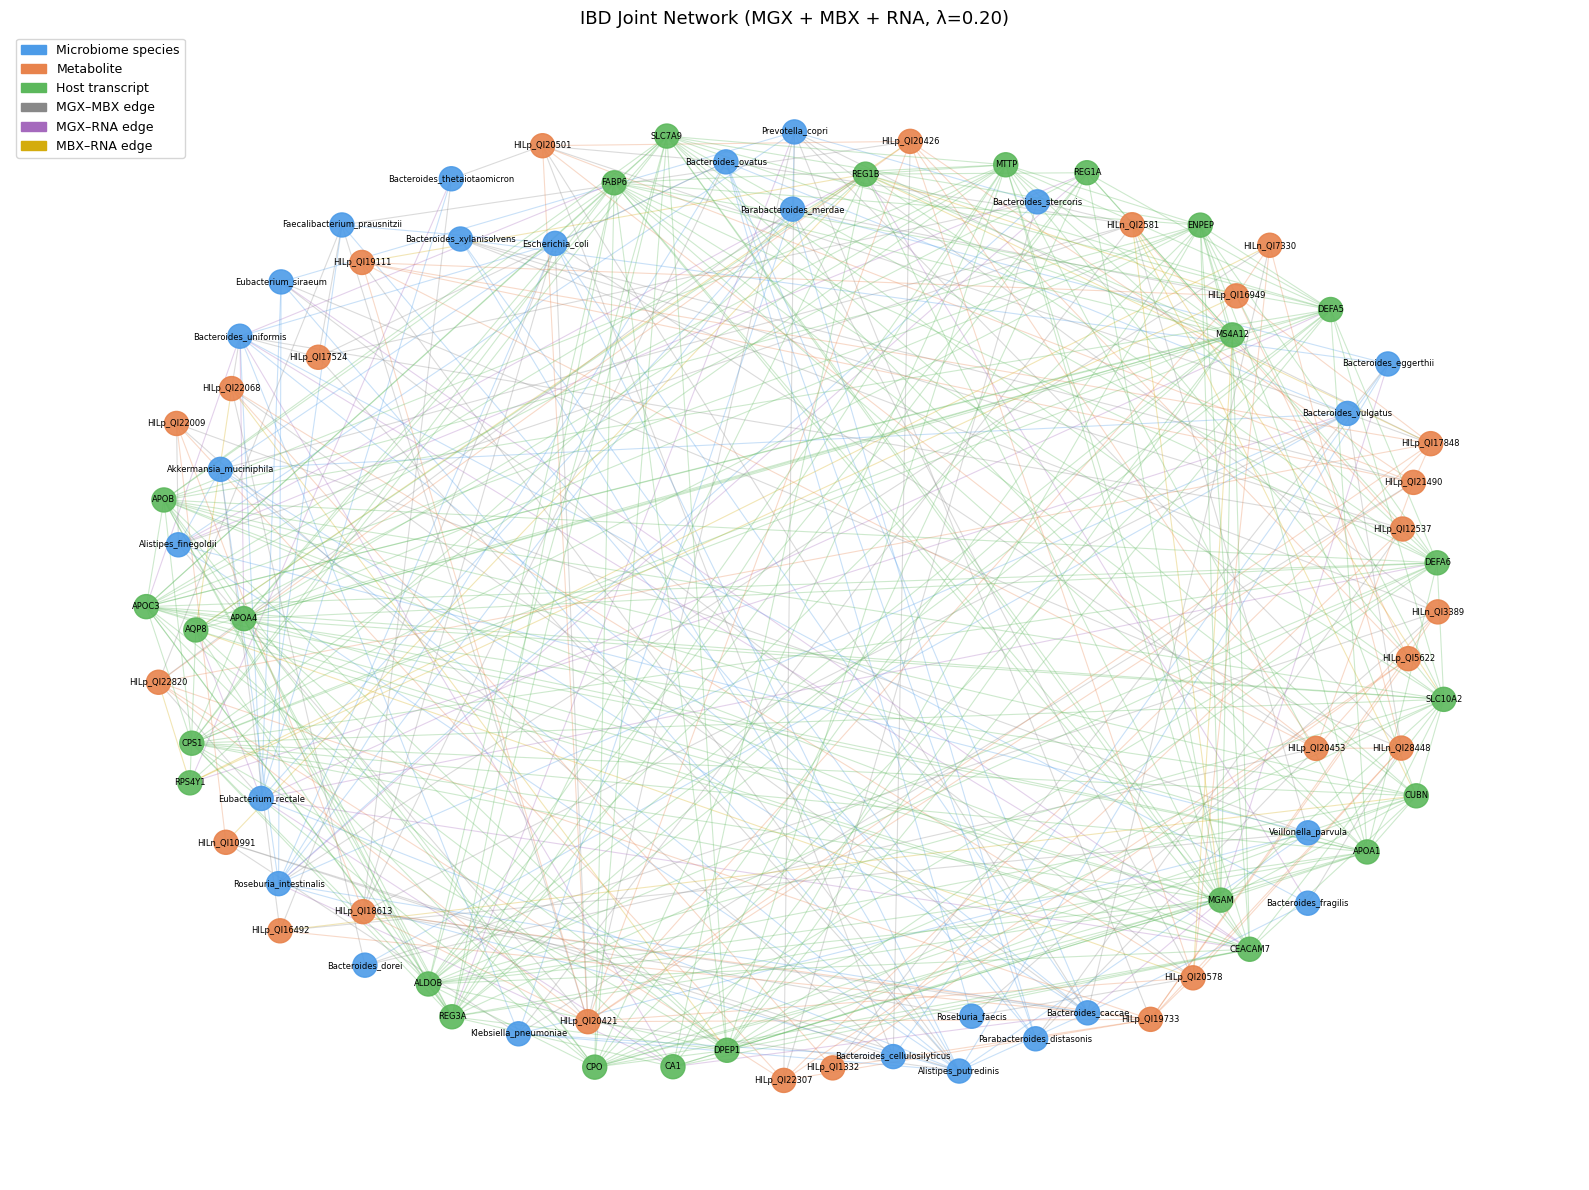

Saved: ../GLASSO/results/ibd/ibd_joint_network.png


In [6]:
# ── Network Visualisation ─────────────────────────────────────────────────────
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

GRAPHML_PATH = "../GLASSO/results/ibd/ibd_joint_network.graphml"

G = nx.read_graphml(GRAPHML_PATH)
print(f"Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}")

# ── Layout ────────────────────────────────────────────────────────────────────
pos = nx.spring_layout(G, seed=42, k=1.5)

# ── Node colours by modality ──────────────────────────────────────────────────
node_colour_map = {
    "microbiome": "#4C9BE8",
    "metabolite": "#E8834C",
    "transcript": "#5CB85C",
}
node_colours = [node_colour_map.get(G.nodes[n].get("modality"), "#cccccc") for n in G.nodes()]

# ── Edge colours by type ──────────────────────────────────────────────────────
edge_colour_map = {
    "mgx-mgx": "#4C9BE8",
    "mbx-mbx": "#E8834C",
    "rna-rna": "#5CB85C",
    "mgx-mbx": "#888888",
    "mgx-rna": "#A569BD",
    "mbx-rna": "#D4AC0D",
}
edge_colours = [edge_colour_map.get(G[u][v].get("edge_type", ""), "#cccccc") for u, v in G.edges()]

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))

nx.draw_networkx_nodes(G, pos, node_color=node_colours, node_size=300, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color=edge_colours, alpha=0.3, width=0.8, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=6, ax=ax)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color="#4C9BE8", label="Microbiome species"),
    mpatches.Patch(color="#E8834C", label="Metabolite"),
    mpatches.Patch(color="#5CB85C", label="Host transcript"),
    mpatches.Patch(color="#888888", label="MGX–MBX edge"),
    mpatches.Patch(color="#A569BD", label="MGX–RNA edge"),
    mpatches.Patch(color="#D4AC0D", label="MBX–RNA edge"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=9)
ax.set_title("IBD Joint Network (MGX + MBX + RNA, λ=0.20)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig("../GLASSO/results/ibd/ibd_joint_network.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../GLASSO/results/ibd/ibd_joint_network.png")
